In [1]:
import os
import sys
project_root = os.path.dirname(os.path.abspath('.'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
__package__ = 'rampa'

from rampa.query.duckdb_tools import DataManager

In [2]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
from rampa.routing.route import Network

# Layers

When a database connection is not provided, DataManager behaves like Data_Collection

In [ ]:
dmanager = DataManager(json_file=project_root +'/Users/mherrero/Documents/madrid_open_data/rampa/data/urls.json', populate=True)
dmanager.download_data()

But if we provide a database, we can populate it

In [4]:
dmanager_db = DataManager(json_file=project_root + '/rampa/data/urls.json', 
                          db_connection=project_root + '/rampa/data/prueba.db', 
                          populate=True)

INFO:rampa.query.arcgis_tools:Loading URL dictionary from JSON file: /Users/mherrero/Documents/madrid_open_data/rampa/data/urls.json
INFO:rampa.query.duckdb_tools:Creating collection of layers from URL dictionary.
  0%|          | 0/87 [00:00<?, ?it/s]INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/AREAS_ACTIVIDADES_PARA_MAYORES/MapServer/0
INFO:rampa.query.duckdb_tools:Stored layer AREAS_ACTIVIDADES_PARA_MAYORES in database with 305 records.
  1%|          | 1/87 [00:12<18:06, 12.63s/it]INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/AREAS_ACTIVIDADES_PARA_MAYORES/MapServer/1
INFO:rampa.query.duckdb_tools:Stored layer EJERCICIOS_PARA_MAYORES in database with 200 records.
  2%|▏         | 2/87 [00:38<28:37, 20.20s/it]INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/ASEOS_PUBLICOS/MapSer

Alternatively, if the database already exist, we can just load the layers onto the manager

In [5]:
dmanager_read = DataManager(json_file=project_root + '/rampa/data/urls.json', 
                          db_connection=project_root + '/rampa/data/prueba.db', 
                          populate=False) 

INFO:rampa.query.arcgis_tools:Loading URL dictionary from JSON file: /Users/mherrero/Documents/madrid_open_data/rampa/data/urls.json


By default, the data is kept in the database and brought only to memory when queried

In [10]:
print(len(dmanager_read.data))
layer = dmanager_read.get_layer_data('AREAS_ACTIVIDADES_PARA_MAYORES')
print(len(dmanager_read.data))

INFO:rampa.query.duckdb_tools:Loaded layer AREAS_ACTIVIDADES_PARA_MAYORES from database: 305 records


0
1


We can load all layers in memory by

In [11]:
dmanager_read.load_all_layers()
print(len(dmanager_read.data))

  0%|          | 0/87 [00:00<?, ?it/s]INFO:rampa.query.duckdb_tools:Loaded layer EJERCICIOS_PARA_MAYORES from database: 0 records
INFO:rampa.query.duckdb_tools:Loaded layer ASEOS_PUBLICOS from database: 118 records
INFO:rampa.query.duckdb_tools:Loaded layer CUIDAR_A_QUIENES_NOS_CUIDAN from database: 21 records
INFO:rampa.query.duckdb_tools:Loaded layer JUNTOS_CONTRA_LA_SOLEDAD from database: 20 records
INFO:rampa.query.duckdb_tools:Loaded layer NOMBRES_DE_BARRIOS from database: 131 records
INFO:rampa.query.duckdb_tools:Loaded layer SECCIONES_CENSALES from database: 2462 records
INFO:rampa.query.duckdb_tools:Loaded layer DENSIDAD_POBLACION from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer EDAD_PROMEDIO from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer PROPORCION_JUVENTUD from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer PROPORCION_ENVEJECIMIENTO from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer PROPORCIO

87


# Routing

We can start by downloading the graph defined by a boundary. The optional argument db allows us to store the graph using duckdb.

In [3]:
madrid = ox.geocoder.geocode_to_gdf('R5326784', by_osmid=True)
net = Network(madrid, db=project_root + '/rampa/data/grafo.db', store=True)

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 165387
Setting CH edge vector of size 495988
Range graph removed 501892 edges of 991976
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Storing network in DuckDB


After it's saved into the DB, we can simply load it from there, without need to download it again

In [4]:
net_db = Network(db=project_root + '/rampa/data/grafo.db')

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 165387
Setting CH edge vector of size 495988
Range graph removed 501892 edges of 991976
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%


Nodes and edges are stored in their corresponding dataframes

In [6]:
net_db.nodes

,x,y
index,,
171946,-3.684443,40.421247
171951,-3.688989,40.417360
171952,-3.688980,40.414991
171953,-3.688901,40.412775
20952893,-3.597241,40.430465
...,...,...
13069374949,-3.759205,40.401607
13069761885,-3.688659,40.477519
13069761886,-3.688402,40.477475


In [7]:
net_db.edges

,from,to,distance
0,171946,11218044065,3.817747
1,171946,1209330272,33.546989
2,171946,3280496563,28.937732
3,171951,26486638,125.173331
4,171951,1209331009,18.732956
...,...,...,...
495983,13069761888,13069761885,18.114956
495984,13069761888,13069761889,22.058976
495985,13069761889,5676730807,70.251765
495986,13069761889,13069761888,22.058976


The routing engine works by invoking route or route_gdf. The first returns a list of nodes, the second a gdf.

In [ ]:
coord1 = (-3.703790, 40.416775)  # Example coordinates for Madrid in (longitude, latitude) format.
coord2 = (-3.72, 40.416775)

In [10]:
ruta_list = net_db.route(coord1, coord2)
ruta_gdf = net_db.route_gdf(coord1, coord2)

In [11]:
ruta_list

array([12289775102, 12289775104, 12289772637, 12289772644,  5302261816,
        5302261817, 12364856138,  5302261818, 12285057987,  5302264621,
          21734253,  5302264622, 12390199759,  8785684064, 11525478885,
       12390199746, 12390199760, 12390199764, 12390199762,    26212782,
        3519909373,  3208363773,    26212781,   345198357,  3267122619,
        3246224683,  7968363540,  3448829236,  1179022604, 11922056428,
       11922056429, 11922056302, 11922056305, 11922010661, 11922056287,
         873727537, 11922056243, 11922056244, 11922056236,   873727549,
       11922025738, 11146396686,  5203926739,  3448829270, 11146434315,
       11146434314,  3175560613,  1179022226,  3835622755,  3835622745,
         255881086,   255881085,   255881077,  1179022431,  1179022420,
         343664662,  1179022287,  1179021838,  1179022033])

<Axes: >

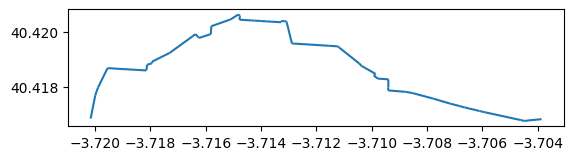

In [12]:
ruta_gdf.plot()

In [12]:
layer = dmanager_read.get_layer_data('ACCESIBILIDAD_ACERAS_2021')

In [11]:
dmanager_read.layers['ACCESIBILIDAD_ACERAS_2021'].url

'https://sigma.madrid.es/hosted/rest/services/OBRAS/ACCESIBILIDAD_ACERAS_2021/MapServer/0'

In [14]:
layer[layer['DISTRITO']=='10. LATINA']

,DISTRITO,CALLE,ACTUACIÓN,SUP_Calzad,SUP_Acera,PP_N,PP_R,Estado,OBJECTID
53,10. LATINA,Calle Ocaña,ACERA Y CALZADA,265.10,669.90,2,2.0,3.0,55
69,10. LATINA,Calle Aramis cv Calle Manuel Muiño,"ACERA, CALZADA Y TALUD",1591.26,1802.59,2,6.0,3.0,71
70,10. LATINA,Calle Aramis,ACERA Y CALZADA,114.16,576.80,2,2.0,3.0,72
72,10. LATINA,Calle Los Yébenes,Acera,0.00,2226.30,2,1.0,3.0,74
180,10. LATINA,Calle Camarena,Acera y calzada,55.00,353.00,0,0.0,3.0,182
181,10. LATINA,Calle Concejal Francisco José Jiménez Martín,ACERA,335.50,1947.15,0,36.0,3.0,183
182,10. LATINA,Calle Aldeanueva de la Vera,ACERA Y CALZADA,1183.00,654.00,0,7.0,3.0,184
183,10. LATINA,Avenida de las Águilas,ACERA,34.00,219.00,0,5.0,3.0,185
196,10. LATINA,Calle Maqueda,Acera y calzada,232.50,2014.00,0,4.0,3.0,198
197,10. LATINA,Calle Seseña,Acera y calzada,393.00,2765.00,8,14.0,3.0,199
